# `mrt_experience` v2 — one second, one row

`mrt_experience` is the robot's sense of the **present**: raw reality (what the camera
sees, where the body is) that the LLM later reads to orient and decide — nothing derived,
nothing interpreted. It is a rolling in-RAM table, not a stored dataset: **one row per
second** — `experience_id, ts, frame (1 fps), pos_x, pos_y, heading` — keeping the last **30
seconds**. Data comes live from Darab's frame API (`logots_api.get_latest_frame()`),
served by his GUI on `localhost:8787` in both real and sim mode.

## How to run

1. `conda run -n logots python src/logots_ui.py` — starts the GUI + API server.
2. In the GUI press **▶ SIM**, pick `experiments/staging_to_action_v2/session_20260725_155329.csv`, leave **LOOP** on.
3. Run this notebook top-to-bottom with the **gemma-lab** kernel.

## 1. Connect

One call to Darab's client proves the link — and that the new pose fields
(`pos_x, pos_y, heading`) are coming through.

In [1]:
import sys, time, threading, base64, io
from collections import deque
from datetime import datetime, timezone

import numpy as np
from PIL import Image

sys.path.insert(0, "/Users/asaphbrosh/Documents/Projects/Plantaf/src")            # Darab's client lives in src/
from logots_api import get_latest_frame

f = get_latest_frame()
print("connected — sim_mode:", f["sim_mode"])
print("frame_id:", f["frame_id"], "| image:", None if f["image"] is None else f["image"].shape)
print("pose: pos_x=%.3f  pos_y=%.3f  heading=%.1f°" % (f["pos_x"], f["pos_y"], f["heading"]))

connected — sim_mode: True
frame_id: 651 | image: (640, 640, 3)
pose: pos_x=-0.383  pos_y=-0.328  heading=330.6°


## 2. The feed's rhythm

The API returns only the *latest* frame; polling faster than frames arrive returns the
same frame again. We poll every **30 ms** — the same rate as Darab's own `api_demo.py`
and ~3× faster than the ~10 Hz feed — and dedupe on `frame_id`, so every frame is seen
exactly once and none twice.

In [2]:
t_end = time.time() + 4.0
stamps, ids, last = [], [], None
while time.time() < t_end:
    fr = get_latest_frame(decode_image=False)     # timing only, skip decode
    if fr["frame_id"] != last:
        stamps.append(time.time()); ids.append(fr["frame_id"]); last = fr["frame_id"]
    time.sleep(0.03)

dt, gaps = np.diff(stamps), np.diff(ids)
print(f"new frames: {len(ids)} in {stamps[-1]-stamps[0]:.1f}s  ->  ~{1/dt.mean():.1f} frames/sec")
print(f"frame_id steps: min={gaps.min()} max={gaps.max()}   (1 everywhere = none missed, none doubled)")

new frames: 38 in 3.9s  ->  ~9.4 frames/sec
frame_id steps: min=-342 max=1   (1 everywhere = none missed, none doubled)


## 3. The table — consecutive, non-overlapping seconds

The previous version emitted overlapping 5 s windows every 2 s — experiences shared
frames and did not tile the timeline. Here each incoming frame lands in the **bucket of
its integer second**; when the second rolls over, the closed bucket becomes exactly one
row. Row *N*+1 starts where row *N* ends: no shared frames, no gaps.

Choices worth naming: `experience_id` starts at **1** and counts up — the grain is the
*experience* (which today spans one second); it is derived from the integer-second offset,
so a second with no frames would break the consecutive numbering loudly instead of being
papered over;
`ts`, `frame` and pose are all taken from the **same instant** — the last frame of the
second; the final partial second at end-of-recording is dropped (rows are full seconds
only). Pose is Darab's **dead-reckoning estimate** (integrated PWM + IMU yaw): it drifts,
and spinning in place changes heading without translation — an estimate, not ground truth.

In [3]:
Y_ROWS = 30                      # RAM window: last 30 seconds (~40 MB)

class SecondTable:
    """1-fps mrt_experience: one closed row per integer second, last Y_ROWS kept."""
    def __init__(self, max_rows=Y_ROWS):
        self.rows = deque(maxlen=max_rows)
        self.emitted = 0                 # rows closed over the whole pass (incl. evicted)
        self._sec = None                 # integer second currently being filled
        self._first_sec = None
        self._bucket = None              # frames of the current second

    def push(self, fr):
        sec = int(datetime.fromisoformat(fr["timestamp"]).timestamp())
        if self._sec is None:
            self._sec = sec
            self._first_sec = sec
            self._bucket = [fr]
        elif sec == self._sec:
            self._bucket.append(fr)      # same second — keep collecting
        else:
            self._close()                # second rolled over — emit the closed one
            self._sec, self._bucket = sec, [fr]

    def _close(self):
        rep = self._bucket[-1]           # representative instant: last frame of the second
        self.rows.append({
            "experience_id": self._sec - self._first_sec + 1,   # 1, 2, 3, …
            "ts":      rep["timestamp"],
            "frame":   rep["image"],
            "pos_x":   rep["pos_x"], "pos_y": rep["pos_y"], "heading": rep["heading"],
            "first_frame_id": self._bucket[0]["frame_id"],   # to prove no overlap
            "last_frame_id":  rep["frame_id"],
            "n_frames": len(self._bucket),
        })
        self.emitted += 1
    # note: the last partial second is never closed — dropped by design

## 4. Capture one clean pass

The sim replays the recording in a loop, so `frame_id` jumps backwards at each restart.
First backward jump = the recording's start (begin collecting); second = we've seen the
whole thing (stop). On the real robot `frame_id` only climbs, so this never fires and the
loop simply runs live.

In [4]:
table = SecondTable()
_stop, _wrapped = threading.Event(), threading.Event()

def _poll_loop():
    last, capturing = None, False
    while not _stop.is_set():
        try:
            fr = get_latest_frame(decode_image=True)   # decode, like api_demo.py
        except Exception:
            time.sleep(0.03); continue                 # 503 before first frame / transient
        if fr["frame_id"] != last:
            if last is not None and fr["frame_id"] < last:   # loop wrap
                if not capturing:
                    capturing = True                   # 1st wrap → recording's start
                else:
                    _wrapped.set(); break              # 2nd wrap → full pass done
            if capturing:
                table.push(fr)
            last = fr["frame_id"]
        time.sleep(0.03)

threading.Thread(target=_poll_loop, daemon=True).start()
print("syncing to the recording's start, then capturing one pass…")
_wrapped.wait(timeout=120)
_stop.set()
print(f"rows emitted over the pass: {table.emitted}  |  kept in RAM window: {len(table.rows)}  |  ended on wrap: {_wrapped.is_set()}")

syncing to the recording's start, then capturing one pass…


rows emitted over the pass: 36  |  kept in RAM window: 30  |  ended on wrap: True


## 5. The table

The RAM window's contents — `frame` shown as its shape only. The frame-id columns make
the no-overlap property visible: each row's `first_frame_id` is its predecessor's
`last_frame_id` + 1.

In [5]:
import pandas as pd

df = pd.DataFrame([{k: (v.shape if k == "frame" and v is not None else v)
                    for k, v in r.items()} for r in table.rows])
df["ts"] = df["ts"].str[11:23]
df

,experience_id,ts,frame,pos_x,pos_y,heading,first_frame_id,last_frame_id,n_frames
0,7,15:53:35.949,"(640, 640, 3)",0.0000,0.0000,57.66,365,373,9
1,8,15:53:36.955,"(640, 640, 3)",0.0000,0.0000,73.84,374,383,10
2,9,15:53:37.914,"(640, 640, 3)",0.0000,0.0000,78.11,384,392,9
3,10,15:53:38.989,"(640, 640, 3)",0.0288,0.1197,76.33,393,402,10
4,11,15:53:39.933,"(640, 640, 3)",0.0785,0.3987,79.01,403,411,9
5,12,15:53:40.946,"(640, 640, 3)",0.1457,0.6948,77.73,412,421,10
6,13,15:53:41.913,"(640, 640, 3)",0.2131,0.9770,75.04,422,430,9
7,14,15:53:42.905,"(640, 640, 3)",0.2793,1.2670,78.13,431,439,9
8,15,15:53:43.964,"(640, 640, 3)",0.2866,1.3017,78.33,440,449,10
9,16,15:53:44.918,"(640, 640, 3)",0.2160,1.0242,73.90,450,458,9


## 6. Six experiences, seen

Experiences 16–21 played back as a GIF at real pace (1 frame = 1 second): six consecutive
rows of `mrt_experience`, i.e. the movement the LLM would see, with the pose travelled
over those six seconds.

experiences 16→21  (6 seconds, 1 fps, real-time)
pose: (0.22, 1.02) 74°  →  (-0.38, -0.33) 70°


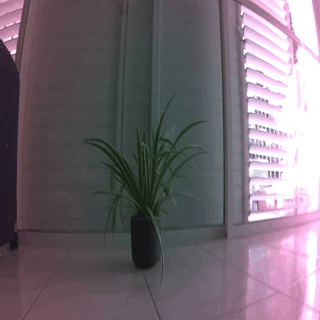

In [6]:
from IPython.display import Image as IPyImage, display

sel = [r for r in table.rows if 16 <= r["experience_id"] <= 21]
assert sel, "experiences 16–21 not in the RAM window"

gif_frames = [Image.fromarray(r["frame"]).resize((320, 320)) for r in sel]
buf = io.BytesIO()
gif_frames[0].save(buf, format="GIF", save_all=True, append_images=gif_frames[1:],
                   duration=1000, loop=0)          # 1000 ms/frame = real-time pace

p0, p1 = sel[0], sel[-1]
print(f"experiences {p0['experience_id']}→{p1['experience_id']}  ({len(sel)} seconds, 1 fps, real-time)")
print(f"pose: ({p0['pos_x']:.2f}, {p0['pos_y']:.2f}) {p0['heading']:.0f}°  →  ({p1['pos_x']:.2f}, {p1['pos_y']:.2f}) {p1['heading']:.0f}°")
display(IPyImage(data=buf.getvalue()))

## 7. Verification

The properties the previous version failed, asserted.

In [7]:
rows = list(table.rows)
eid = np.array([r["experience_id"] for r in rows])
first = np.array([r["first_frame_id"] for r in rows])
last_ = np.array([r["last_frame_id"] for r in rows])

assert (np.diff(eid) == 1).all(), "experience_id not consecutive — an experience is missing"
assert (first[1:] == last_[:-1] + 1).all(), "rows overlap or skip frames"
assert (last_ >= first).all(), "negative frame span"
px = np.array([r["pos_x"] for r in rows]); py = np.array([r["pos_y"] for r in rows])
hd = np.array([r["heading"] for r in rows])
assert px.std() > 0 and py.std() > 0 and hd.std() > 0, "pose never varies — robot didn't move?"
ch = rows[len(rows)//2]["frame"].reshape(-1, 3).mean(0)
assert abs(ch[0]-ch[1]) > 1 or abs(ch[1]-ch[2]) > 1, "frames look grayscale"
assert len(rows) == min(Y_ROWS, table.emitted), "RAM window size wrong"

print(f"ALL CHECKS PASS — {len(rows)} consecutive non-overlapping seconds "
      f"(experience_id {eid[0]}→{eid[-1]}), pose varies, frames in colour")

ALL CHECKS PASS — 30 consecutive non-overlapping seconds (experience_id 7→36), pose varies, frames in colour


## Recap

One row = one experience (one second): `experience_id, ts, frame (1 fps), pos_x, pos_y, heading` — consecutive,
non-overlapping, last 30 s in RAM. No audio (speech reaches the LLM via a trigger path,
separately); pose is a drifting dead-reckoning estimate. Next step: the reflective layer —
handing a slice of these rows to Gemma to orient and choose an action.